# 04 — Audio Preprocessing

This notebook prepares the cleaned ICBHI respiratory sound recordings for feature engineering and machine-learning experiments.

The preprocessing pipeline includes:

1. Loading cleaned recording and cycle metadata
2. Inspecting original audio properties
3. Defining a common sampling-rate strategy
4. Extracting annotated respiratory cycles
5. Validating extracted segments
6. Applying amplitude normalization
7. Handling variable-length respiratory cycles
8. Saving preprocessing metadata

The original diagnosis labels are not modified during preprocessing.

Disease classification remains a patient-level task, while respiratory sound classification remains a cycle-level task.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"

AUDIO_OUTPUT_DIR = PROCESSED_DATA_DIR / "audio"
AUDIO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Audio output directory:", AUDIO_OUTPUT_DIR)

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification
Audio output directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio


In [2]:
patients_df = pd.read_csv(
    PROCESSED_DATA_DIR / "patients_clean.csv"
)

recordings_df = pd.read_csv(
    PROCESSED_DATA_DIR / "recordings_clean.csv"
)

cycles_df = pd.read_csv(
    PROCESSED_DATA_DIR / "cycles_clean.csv"
)

audio_info_df = pd.read_csv(
    PROCESSED_DATA_DIR / "audio_info_clean.csv"
)

print("Patients:", patients_df.shape)
print("Recordings:", recordings_df.shape)
print("Cycles:", cycles_df.shape)
print("Audio info:", audio_info_df.shape)

Patients: (126, 7)
Recordings: (920, 7)
Cycles: (6898, 12)
Audio info: (920, 4)


In [3]:
sampling_rate_summary = (
    audio_info_df["sample_rate"]
    .value_counts()
    .sort_index()
    .rename_axis("sample_rate")
    .reset_index(name="recordings")
)

sampling_rate_summary["percentage"] = (
    sampling_rate_summary["recordings"]
    / len(audio_info_df)
    * 100
)

sampling_rate_summary

,sample_rate,recordings,percentage
0,4000,90,9.782609
1,10000,6,0.652174
2,44100,824,89.565217


## Sampling-Rate Standardization

The cleaned ICBHI recordings contain three sampling rates:

- 4,000 Hz
- 10,000 Hz
- 44,100 Hz

A common sampling rate is required so that the extracted time-domain,
frequency-domain, and time-frequency features have a consistent sampling
basis across recordings.

For the main preprocessing pipeline, a target sampling rate of **4,000 Hz**
is selected.

This choice avoids upsampling the recordings that were originally acquired
at 4,000 Hz, which would increase the number of samples but would not recover
information that was not captured during the original acquisition. Recordings
with higher sampling rates will therefore be downsampled to 4,000 Hz.

This standardization introduces a trade-off because downsampling the
44,100-Hz recordings removes frequency information above the corresponding
Nyquist limit. The effect of this decision will therefore be considered
when interpreting the results of subsequent feature extraction and model
evaluation.

The same target sampling rate will be applied consistently to all extracted
respiratory cycles to ensure comparable representations for data mining and
machine-learning experiments.

In [4]:
TARGET_SR = 4000

print("Target sampling rate:", TARGET_SR, "Hz")
print("Target Nyquist frequency:", TARGET_SR / 2, "Hz")

Target sampling rate: 4000 Hz
Target Nyquist frequency: 2000.0 Hz


In [5]:
sample_recording = recordings_df.iloc[0]

sample_recording

patient_id                                                        101
recording_id                                                      1b1
chest_location                                                     Al
acquisition_mode                                                   sc
equipment                                                    Meditron
wav_path            /Users/vs/Sem 5/Respiratory-Disease-Classifica...
official_split                                                   test
Name: 0, dtype: object

In [6]:
sample_wav_path = Path(sample_recording["wav_path"])

print("Audio path:", sample_wav_path)
print("File exists:", sample_wav_path.exists())

Audio path: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/raw/ICBHI/101_1b1_Al_sc_Meditron.wav
File exists: True


In [7]:
sample_audio, sample_sr = librosa.load(
    sample_wav_path,
    sr=None,
    mono=True
)

print("Original sampling rate:", sample_sr, "Hz")
print("Number of samples:", len(sample_audio))
print("Duration:", len(sample_audio) / sample_sr, "seconds")
print("Minimum amplitude:", sample_audio.min())
print("Maximum amplitude:", sample_audio.max())

Original sampling rate: 44100 Hz
Number of samples: 882000
Duration: 20.0 seconds
Minimum amplitude: -0.20022571
Maximum amplitude: 0.4147644


In [8]:
sample_cycles = cycles_df[
    (cycles_df["patient_id"] == sample_recording["patient_id"]) &
    (cycles_df["recording_id"] == sample_recording["recording_id"])
].copy()

sample_cycles

,patient_id,recording_id,chest_location,acquisition_mode,equipment,wav_path,cycle_number,start_time,end_time,crackles,wheezes,sound_label
0,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,1,0.036,0.579,0,0,Normal
1,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,2,0.579,2.450,0,0,Normal
2,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,3,2.450,3.893,0,0,Normal
3,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,4,3.893,5.793,0,0,Normal
4,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,5,5.793,7.521,0,0,Normal
5,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,6,7.521,9.279,0,0,Normal
6,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,7,9.279,11.150,0,0,Normal
7,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,8,11.150,13.036,0,0,Normal
8,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,9,13.036,14.721,0,0,Normal
9,101,1b1,Al,sc,Meditron,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,10,14.721,16.707,0,0,Normal


In [9]:
print("Number of annotated cycles:", len(sample_cycles))

sample_cycles[
    [
        "cycle_number",
        "start_time",
        "end_time",
        "crackles",
        "wheezes",
        "sound_label"
    ]
]

Number of annotated cycles: 23


,cycle_number,start_time,end_time,crackles,wheezes,sound_label
0,1,0.036,0.579,0,0,Normal
1,2,0.579,2.450,0,0,Normal
2,3,2.450,3.893,0,0,Normal
3,4,3.893,5.793,0,0,Normal
4,5,5.793,7.521,0,0,Normal
5,6,7.521,9.279,0,0,Normal
6,7,9.279,11.150,0,0,Normal
7,8,11.150,13.036,0,0,Normal
8,9,13.036,14.721,0,0,Normal
9,10,14.721,16.707,0,0,Normal


In [10]:
sample_wav_path = Path(sample_recording["wav_path"])

print("Audio path:", sample_wav_path)
print("File exists:", sample_wav_path.exists())

Audio path: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/raw/ICBHI/101_1b1_Al_sc_Meditron.wav
File exists: True


In [11]:
sample_audio, sample_sr = librosa.load(
    sample_wav_path,
    sr=None,
    mono=True
)

print("Original sampling rate:", sample_sr, "Hz")
print("Number of samples:", len(sample_audio))
print("Duration:", len(sample_audio) / sample_sr, "seconds")
print("Minimum amplitude:", sample_audio.min())
print("Maximum amplitude:", sample_audio.max())

Original sampling rate: 44100 Hz
Number of samples: 882000
Duration: 20.0 seconds
Minimum amplitude: -0.20022571
Maximum amplitude: 0.4147644


In [12]:
first_cycle = sample_cycles[
    sample_cycles["chest_location"] == "Al"
].iloc[0]

first_cycle

patient_id                                                        101
recording_id                                                      1b1
chest_location                                                     Al
acquisition_mode                                                   sc
equipment                                                    Meditron
wav_path            /Users/vs/Sem 5/Respiratory-Disease-Classifica...
cycle_number                                                        1
start_time                                                      0.036
end_time                                                        0.579
crackles                                                            0
wheezes                                                             0
sound_label                                                    Normal
Name: 0, dtype: object

In [13]:
start_time = first_cycle["start_time"]
end_time = first_cycle["end_time"]

start_sample = int(round(start_time * sample_sr))
end_sample = int(round(end_time * sample_sr))

cycle_audio = sample_audio[start_sample:end_sample]

print("Start time:", start_time, "seconds")
print("End time:", end_time, "seconds")
print("Cycle duration:", end_time - start_time, "seconds")
print("Start sample:", start_sample)
print("End sample:", end_sample)
print("Extracted samples:", len(cycle_audio))
print("Expected samples:", end_sample - start_sample)

Start time: 0.036 seconds
End time: 0.579 seconds
Cycle duration: 0.5429999999999999 seconds
Start sample: 1588
End sample: 25534
Extracted samples: 23946
Expected samples: 23946


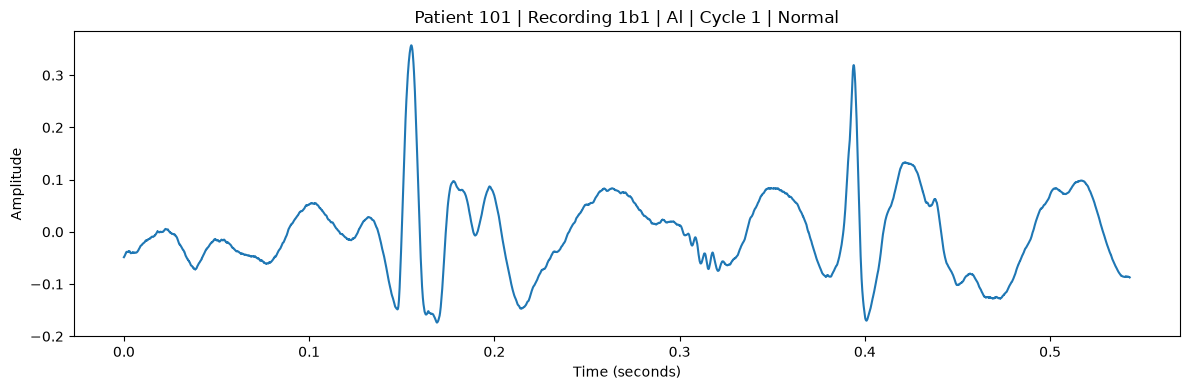

In [14]:
time_axis = np.arange(len(cycle_audio)) / sample_sr

plt.figure(figsize=(12, 4))
plt.plot(time_axis, cycle_audio)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    f"Patient 101 | Recording 1b1 | Al | Cycle 1 | Normal"
)
plt.tight_layout()
plt.show()

In [15]:
cycle_audio_4k = librosa.resample(
    cycle_audio,
    orig_sr=sample_sr,
    target_sr=TARGET_SR
)

print("Original cycle samples:", len(cycle_audio))
print("Original sample rate:", sample_sr)

print("Resampled cycle samples:", len(cycle_audio_4k))
print("Target sample rate:", TARGET_SR)

print(
    "Expected resampled samples:",
    round((end_time - start_time) * TARGET_SR)
)

print(
    "Resampled duration:",
    len(cycle_audio_4k) / TARGET_SR,
    "seconds"
)

Original cycle samples: 23946
Original sample rate: 44100
Resampled cycle samples: 2172
Target sample rate: 4000
Expected resampled samples: 2172
Resampled duration: 0.543 seconds


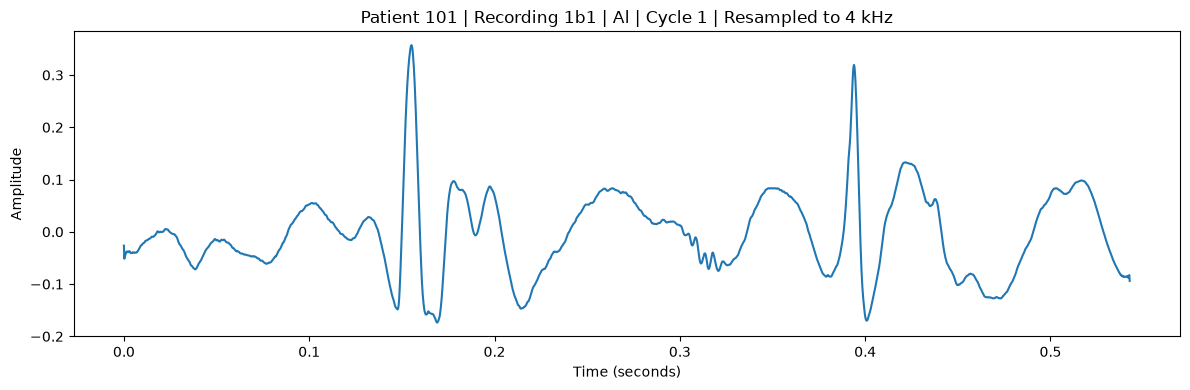

In [16]:
time_axis_4k = np.arange(len(cycle_audio_4k)) / TARGET_SR

plt.figure(figsize=(12, 4))
plt.plot(time_axis_4k, cycle_audio_4k)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    "Patient 101 | Recording 1b1 | Al | Cycle 1 | Resampled to 4 kHz"
)
plt.tight_layout()
plt.show()

In [17]:
original_peak = np.max(np.abs(cycle_audio_4k))
original_rms = np.sqrt(np.mean(cycle_audio_4k ** 2))

if original_peak > 0:
    normalized_cycle = cycle_audio_4k / original_peak
else:
    normalized_cycle = cycle_audio_4k.copy()

normalized_peak = np.max(np.abs(normalized_cycle))
normalized_rms = np.sqrt(np.mean(normalized_cycle ** 2))

print("Original peak amplitude:", original_peak)
print("Original RMS:", original_rms)

print("Normalized peak amplitude:", normalized_peak)
print("Normalized RMS:", normalized_rms)

print("Normalized minimum:", normalized_cycle.min())
print("Normalized maximum:", normalized_cycle.max())

Original peak amplitude: 0.35704014
Original RMS: 0.07982144
Normalized peak amplitude: 1.0
Normalized RMS: 0.2235643
Normalized minimum: -0.48670444
Normalized maximum: 1.0


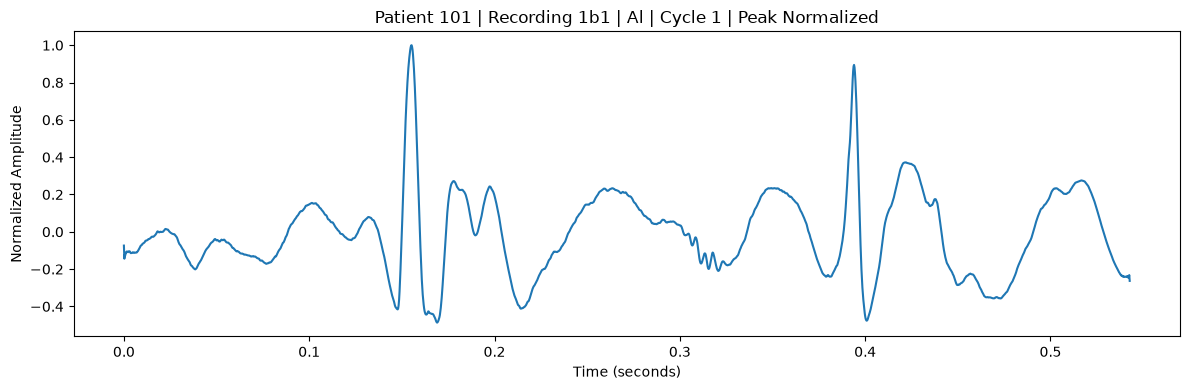

In [18]:
time_axis_norm = np.arange(len(normalized_cycle)) / TARGET_SR

plt.figure(figsize=(12, 4))
plt.plot(time_axis_norm, normalized_cycle)
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title(
    "Patient 101 | Recording 1b1 | Al | Cycle 1 | Peak Normalized"
)
plt.tight_layout()
plt.show()

## Sampling-Rate Standardization

The cleaned ICBHI dataset contains recordings sampled at 4,000 Hz,
10,000 Hz, and 44,100 Hz.

A common sampling rate is required for consistent audio representation,
particularly for time-frequency features, spectrogram-based models, and
comparability of extracted features.

The primary preprocessing pipeline uses **4,000 Hz** as the standardized
sampling rate. This provides a computationally efficient and uniform
representation and does not require upsampling the recordings originally
acquired at 4,000 Hz.

However, downsampling the 10,000-Hz and 44,100-Hz recordings to 4,000 Hz
removes information above the approximately 2-kHz Nyquist frequency.
Therefore, the choice of 4,000 Hz is treated as a methodological design
decision rather than an assumption that higher-frequency information is
irrelevant.

A sampling-rate sensitivity experiment using a higher target sampling rate
(e.g., 10,000 Hz) can subsequently be used to determine whether retaining
additional frequency information provides a meaningful improvement in
classification performance.

In [19]:
PROCESSED_CYCLES_DIR = (
    PROCESSED_DATA_DIR / "audio" / "cycles"
)

PROCESSED_CYCLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed cycle directory:")
print(PROCESSED_CYCLES_DIR)

Processed cycle directory:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles


In [ ]:
## Full-Dataset Respiratory-Cycle Preprocessing

The validated preprocessing pipeline is now applied to all annotated respiratory cycles.

Each cycle is:

1. Extracted from the original WAV using the annotated start/end times.
2. Resampled to 4,000 Hz.
3. Peak-normalized.
4. Validated for non-empty and finite values.
5. Saved as an individual WAV file.

The original cycle metadata is retained in `processed_cycles.csv`.

Processing errors are recorded rather than stopping the entire pipeline.

In [20]:
from tqdm.auto import tqdm

PROCESSED_CYCLES_DIR = (
    PROCESSED_DATA_DIR / "audio" / "cycles"
)

PROCESSED_CYCLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Add diagnosis to cycle metadata
cycles_processing_df = cycles_df.merge(
    patients_df[["patient_id", "diagnosis"]],
    on="patient_id",
    how="left",
    validate="many_to_one"
)

print("Cycles to process:", len(cycles_processing_df))
print("Target sample rate:", TARGET_SR)
print("Output directory:", PROCESSED_CYCLES_DIR)

Cycles to process: 6898
Target sample rate: 4000
Output directory: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles


In [21]:
processed_records = []
processing_errors = []

# Cache loaded recordings so each WAV is read only once
audio_cache = {}

for idx, row in tqdm(
    cycles_processing_df.iterrows(),
    total=len(cycles_processing_df),
    desc="Processing respiratory cycles"
):
    
    try:
        patient_id = int(row["patient_id"])
        recording_id = str(row["recording_id"])
        chest_location = str(row["chest_location"])
        cycle_number = int(row["cycle_number"])
        
        wav_path = Path(row["wav_path"])
        
        # Load each original recording only once
        cache_key = str(wav_path)
        
        if cache_key not in audio_cache:
            audio, original_sr = librosa.load(
                wav_path,
                sr=None,
                mono=True
            )
            
            audio_cache[cache_key] = (
                audio,
                original_sr
            )
        else:
            audio, original_sr = audio_cache[cache_key]
        
        # Preprocess the annotated respiratory cycle
        processed_audio, metadata = preprocess_cycle(
            audio=audio,
            original_sr=original_sr,
            start_time=float(row["start_time"]),
            end_time=float(row["end_time"]),
            target_sr=TARGET_SR
        )
        
        # Additional validation
        if len(processed_audio) == 0:
            raise ValueError("Processed cycle is empty.")
        
        if not np.all(np.isfinite(processed_audio)):
            raise ValueError(
                "Processed cycle contains NaN or infinite values."
            )
        
        # Create patient-specific output directory
        patient_dir = (
            PROCESSED_CYCLES_DIR / str(patient_id)
        )
        patient_dir.mkdir(
            parents=True,
            exist_ok=True
        )
        
        # Cycle identity includes chest location because
        # cycle numbers restart for different chest locations.
        output_filename = (
            f"{recording_id}_"
            f"{chest_location}_"
            f"{cycle_number:03d}.wav"
        )
        
        output_path = patient_dir / output_filename
        
        # Save normalized audio as 16-bit PCM WAV
        sf.write(
            output_path,
            processed_audio,
            TARGET_SR,
            subtype="PCM_16"
        )
        
        # Store processing metadata
        processed_records.append({
            "patient_id": patient_id,
            "diagnosis": row["diagnosis"],
            "recording_id": recording_id,
            "chest_location": chest_location,
            "acquisition_mode": row["acquisition_mode"],
            "equipment": row["equipment"],
            "cycle_number": cycle_number,
            "sound_label": row["sound_label"],
            "crackles": int(row["crackles"]),
            "wheezes": int(row["wheezes"]),
            "start_time": float(row["start_time"]),
            "end_time": float(row["end_time"]),
            "original_sample_rate": int(original_sr),
            "target_sample_rate": TARGET_SR,
            "original_samples": metadata["original_samples"],
            "processed_samples": metadata["processed_samples"],
            "original_duration": metadata["original_duration"],
            "processed_duration": metadata["processed_duration"],
            "original_peak": metadata["original_peak"],
            "original_rms": metadata["original_rms"],
            "normalized_peak": metadata["normalized_peak"],
            "processed_path": str(
                output_path.relative_to(PROCESSED_DATA_DIR)
            ),
            "processing_status": "success"
        })
        
    except Exception as e:
        
        processing_errors.append({
            "patient_id": row["patient_id"],
            "recording_id": row["recording_id"],
            "chest_location": row["chest_location"],
            "cycle_number": row["cycle_number"],
            "wav_path": row["wav_path"],
            "error": str(e),
            "processing_status": "failed"
        })

print("\nProcessing complete.")
print("Successful cycles:", len(processed_records))
print("Failed cycles:", len(processing_errors))

Processing respiratory cycles:   0%|          | 0/6898 [00:00<?, ?it/s]


Processing complete.
Successful cycles: 0
Failed cycles: 6898


In [22]:
processing_errors_df = pd.DataFrame(processing_errors)

print("Number of errors:", len(processing_errors_df))

processing_errors_df["error"].value_counts().head(10)

Number of errors: 6898


error
name 'preprocess_cycle' is not defined    6898
Name: count, dtype: int64

In [23]:
processing_errors_df.head()

,patient_id,recording_id,chest_location,cycle_number,wav_path,error,processing_status
0,101,1b1,Al,1,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,name 'preprocess_cycle' is not defined,failed
1,101,1b1,Al,2,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,name 'preprocess_cycle' is not defined,failed
2,101,1b1,Al,3,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,name 'preprocess_cycle' is not defined,failed
3,101,1b1,Al,4,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,name 'preprocess_cycle' is not defined,failed
4,101,1b1,Al,5,/Users/vs/Sem 5/Respiratory-Disease-Classifica...,name 'preprocess_cycle' is not defined,failed


In [24]:
print(processing_errors_df.iloc[0]["error"])

name 'preprocess_cycle' is not defined


In [25]:
def preprocess_cycle(
    audio,
    original_sr,
    start_time,
    end_time,
    target_sr=4000
):
    """
    Extract, resample, and peak-normalize one annotated respiratory cycle.
    """

    # Convert annotation times to original sample indices
    start_sample = int(round(start_time * original_sr))
    end_sample = int(round(end_time * original_sr))

    # Validate boundaries
    if start_sample < 0:
        raise ValueError("Start sample is negative.")

    if end_sample <= start_sample:
        raise ValueError("End sample must be greater than start sample.")

    if start_sample >= len(audio):
        raise ValueError("Start sample is outside the audio.")

    # Prevent the end from exceeding the recording
    end_sample = min(end_sample, len(audio))

    # Extract annotated cycle
    cycle = audio[start_sample:end_sample]

    if len(cycle) == 0:
        raise ValueError("Extracted cycle is empty.")

    # Original statistics
    original_duration = len(cycle) / original_sr
    original_peak = float(np.max(np.abs(cycle)))
    original_rms = float(np.sqrt(np.mean(cycle ** 2)))

    # Resample to target sampling rate
    if original_sr != target_sr:
        cycle_resampled = librosa.resample(
            cycle,
            orig_sr=original_sr,
            target_sr=target_sr
        )
    else:
        cycle_resampled = cycle.copy()

    if len(cycle_resampled) == 0:
        raise ValueError("Resampled cycle is empty.")

    # Peak normalization
    processed_peak = float(
        np.max(np.abs(cycle_resampled))
    )

    if processed_peak > 0:
        normalized_cycle = (
            cycle_resampled / processed_peak
        )
    else:
        normalized_cycle = cycle_resampled.copy()

    # Final statistics
    normalized_peak = float(
        np.max(np.abs(normalized_cycle))
    )

    processed_duration = (
        len(normalized_cycle) / target_sr
    )

    metadata = {
        "start_sample": start_sample,
        "end_sample": end_sample,
        "original_samples": len(cycle),
        "processed_samples": len(normalized_cycle),
        "original_duration": original_duration,
        "processed_duration": processed_duration,
        "original_peak": original_peak,
        "original_rms": original_rms,
        "normalized_peak": normalized_peak,
        "target_sr": target_sr,
    }

    return (
        normalized_cycle.astype(np.float32),
        metadata
    )

In [26]:
print(preprocess_cycle)

<function preprocess_cycle at 0x112b52a30>


In [27]:
test_cycle, test_metadata = preprocess_cycle(
    audio=sample_audio,
    original_sr=sample_sr,
    start_time=first_cycle["start_time"],
    end_time=first_cycle["end_time"],
    target_sr=TARGET_SR
)

print("Processed samples:", len(test_cycle))
print("Processed duration:", test_metadata["processed_duration"])
print("Original duration:", test_metadata["original_duration"])
print("Original peak:", test_metadata["original_peak"])
print("Original RMS:", test_metadata["original_rms"])
print("Normalized peak:", test_metadata["normalized_peak"])
print("Target sample rate:", test_metadata["target_sr"])

Processed samples: 2172
Processed duration: 0.543
Original duration: 0.5429931972789116
Original peak: 0.35748291015625
Original RMS: 0.0798293948173523
Normalized peak: 1.0
Target sample rate: 4000


In [28]:
processed_records = []
processing_errors = []

# Clear the audio cache from any previous attempt
audio_cache = {}

print("Ready to process:", len(cycles_processing_df), "cycles")

Ready to process: 6898 cycles


In [29]:
from tqdm.auto import tqdm

for idx, row in tqdm(
    cycles_processing_df.iterrows(),
    total=len(cycles_processing_df),
    desc="Processing respiratory cycles"
):
    
    try:
        patient_id = int(row["patient_id"])
        recording_id = str(row["recording_id"])
        chest_location = str(row["chest_location"])
        cycle_number = int(row["cycle_number"])
        
        wav_path = Path(row["wav_path"])
        cache_key = str(wav_path)
        
        # Load each original recording only once
        if cache_key not in audio_cache:
            audio, original_sr = librosa.load(
                wav_path,
                sr=None,
                mono=True
            )
            audio_cache[cache_key] = (
                audio,
                original_sr
            )
        else:
            audio, original_sr = audio_cache[cache_key]
        
        # Preprocess the annotated cycle
        processed_audio, metadata = preprocess_cycle(
            audio=audio,
            original_sr=original_sr,
            start_time=float(row["start_time"]),
            end_time=float(row["end_time"]),
            target_sr=TARGET_SR
        )
        
        # Validate processed audio
        if len(processed_audio) == 0:
            raise ValueError("Processed cycle is empty.")
        
        if not np.all(np.isfinite(processed_audio)):
            raise ValueError(
                "Processed cycle contains NaN or infinite values."
            )
        
        # Patient-specific directory
        patient_dir = (
            PROCESSED_CYCLES_DIR / str(patient_id)
        )
        patient_dir.mkdir(
            parents=True,
            exist_ok=True
        )
        
        # cycle_number restarts for different chest locations,
        # therefore chest_location is part of the filename.
        output_filename = (
            f"{recording_id}_"
            f"{chest_location}_"
            f"{cycle_number:03d}.wav"
        )
        
        output_path = patient_dir / output_filename
        
        # Save normalized audio
        sf.write(
            output_path,
            processed_audio,
            TARGET_SR,
            subtype="PCM_16"
        )
        
        # Store metadata
        processed_records.append({
            "patient_id": patient_id,
            "diagnosis": row["diagnosis"],
            "recording_id": recording_id,
            "chest_location": chest_location,
            "acquisition_mode": row["acquisition_mode"],
            "equipment": row["equipment"],
            "cycle_number": cycle_number,
            "sound_label": row["sound_label"],
            "crackles": int(row["crackles"]),
            "wheezes": int(row["wheezes"]),
            "start_time": float(row["start_time"]),
            "end_time": float(row["end_time"]),
            "original_sample_rate": int(original_sr),
            "target_sample_rate": TARGET_SR,
            "original_samples": metadata["original_samples"],
            "processed_samples": metadata["processed_samples"],
            "original_duration": metadata["original_duration"],
            "processed_duration": metadata["processed_duration"],
            "original_peak": metadata["original_peak"],
            "original_rms": metadata["original_rms"],
            "normalized_peak": metadata["normalized_peak"],
            "processed_path": str(
                output_path.relative_to(PROCESSED_DATA_DIR)
            ),
            "processing_status": "success"
        })
        
    except Exception as e:
        
        processing_errors.append({
            "patient_id": row["patient_id"],
            "recording_id": row["recording_id"],
            "chest_location": row["chest_location"],
            "cycle_number": row["cycle_number"],
            "wav_path": row["wav_path"],
            "error": str(e),
            "processing_status": "failed"
        })

print("\nProcessing complete.")
print("Successful cycles:", len(processed_records))
print("Failed cycles:", len(processing_errors))

Processing respiratory cycles:   0%|          | 0/6898 [00:00<?, ?it/s]


Processing complete.
Successful cycles: 6898
Failed cycles: 0


In [30]:
processed_cycles_df = pd.DataFrame(processed_records)
processing_errors_df = pd.DataFrame(processing_errors)

print("Processed cycles:", processed_cycles_df.shape)
print("Processing errors:", processing_errors_df.shape)

Processed cycles: (6898, 23)
Processing errors: (0, 0)


In [31]:
processed_cycles_path = (
    PROCESSED_DATA_DIR / "processed_cycles.csv"
)

processing_errors_path = (
    PROCESSED_DATA_DIR / "processing_errors.csv"
)

processed_cycles_df.to_csv(
    processed_cycles_path,
    index=False
)

processing_errors_df.to_csv(
    processing_errors_path,
    index=False
)

print("Saved processed metadata:")
print(processed_cycles_path)

print("\nSaved processing errors:")
print(processing_errors_path)

Saved processed metadata:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/processed_cycles.csv

Saved processing errors:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/processing_errors.csv


In [32]:
print("===== BASIC VALIDATION =====")

print("Input cycles:", len(cycles_df))
print("Processed cycles:", len(processed_cycles_df))
print("Processing failures:", len(processing_errors_df))

print("\n===== TARGET SAMPLE RATE =====")

print(
    processed_cycles_df["target_sample_rate"]
    .value_counts()
    .sort_index()
)

print("\n===== PROCESSING STATUS =====")

print(
    processed_cycles_df["processing_status"]
    .value_counts()
)

print("\n===== SOUND LABELS =====")

print(
    processed_cycles_df["sound_label"]
    .value_counts()
)

print("\n===== DIAGNOSIS =====")

print(
    processed_cycles_df["diagnosis"]
    .value_counts()
)

===== BASIC VALIDATION =====
Input cycles: 6898
Processed cycles: 6898
Processing failures: 0

===== TARGET SAMPLE RATE =====
target_sample_rate
4000    6898
Name: count, dtype: int64

===== PROCESSING STATUS =====
processing_status
success    6898
Name: count, dtype: int64

===== SOUND LABELS =====
sound_label
Normal      3642
Crackles    1864
Wheezes      886
Both         506
Name: count, dtype: int64

===== DIAGNOSIS =====
diagnosis
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64


In [33]:
cycle_id_columns = [
    "patient_id",
    "recording_id",
    "chest_location",
    "cycle_number"
]

duplicate_cycle_ids = processed_cycles_df.duplicated(
    subset=cycle_id_columns
).sum()

print("Duplicate processed cycle IDs:", duplicate_cycle_ids)

Duplicate processed cycle IDs: 0


In [34]:
missing_files = []

for path in processed_cycles_df["processed_path"]:
    full_path = PROCESSED_DATA_DIR / path
    
    if not full_path.exists():
        missing_files.append(str(full_path))

print("Expected processed files:", len(processed_cycles_df))
print("Missing processed files:", len(missing_files))

Expected processed files: 6898
Missing processed files: 0


In [35]:
sample_processed_path = (
    PROCESSED_DATA_DIR /
    processed_cycles_df.iloc[0]["processed_path"]
)

saved_audio, saved_sr = sf.read(
    sample_processed_path
)

print("File:", sample_processed_path)
print("Sample rate:", saved_sr)
print("Samples:", len(saved_audio))
print("Duration:", len(saved_audio) / saved_sr)
print("Minimum:", saved_audio.min())
print("Maximum:", saved_audio.max())

File: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/audio/cycles/101/1b1_Al_001.wav
Sample rate: 4000
Samples: 2172
Duration: 0.543
Minimum: -0.486724853515625
Maximum: 0.999969482421875


In [36]:
duration_difference = (
    processed_cycles_df["processed_duration"]
    - processed_cycles_df["original_duration"]
)

print("Maximum absolute duration difference:",
      duration_difference.abs().max())

print("Mean absolute duration difference:",
      duration_difference.abs().mean())

print("\nProcessed duration statistics:")
print(
    processed_cycles_df["processed_duration"].describe()
)

Maximum absolute duration difference: 0.0002477324263043812
Mean absolute duration difference: 9.71956937795851e-05

Processed duration statistics:
count    6898.000000
mean        2.700606
std         1.172531
min         0.200000
25%         1.932250
50%         2.537000
75%         3.369250
max        16.163000
Name: processed_duration, dtype: float64


In [37]:
print(
    processed_cycles_df["normalized_peak"].describe()
)

print(
    "Cycles with normalized peak != 1:",
    (
        ~np.isclose(
            processed_cycles_df["normalized_peak"],
            1.0
        )
    ).sum()
)

count    6898.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: normalized_peak, dtype: float64
Cycles with normalized peak != 1: 0


In [38]:
processed_cycles_df[
    ["original_sample_rate", "target_sample_rate"]
].drop_duplicates().sort_values("original_sample_rate")

,original_sample_rate,target_sample_rate
42,4000,4000
6778,10000,4000
0,44100,4000


In [39]:
processed_cycles_df["original_sample_rate"].value_counts().sort_index()

original_sample_rate
4000     1016
10000      61
44100    5821
Name: count, dtype: int64

In [40]:
processed_cycles_df[
    processed_cycles_df["original_sample_rate"] == 4000
].iloc[0][
    [
        "patient_id",
        "recording_id",
        "chest_location",
        "cycle_number",
        "original_sample_rate",
        "target_sample_rate",
        "original_duration",
        "processed_duration",
        "processed_path"
    ]
]

patient_id                                          104
recording_id                                        1b1
chest_location                                       Al
cycle_number                                          1
original_sample_rate                               4000
target_sample_rate                                 4000
original_duration                                 1.877
processed_duration                                1.877
processed_path          audio/cycles/104/1b1_Al_001.wav
Name: 42, dtype: object

In [41]:
processed_cycles_df[
    processed_cycles_df["original_sample_rate"] == 10000
].iloc[0][
    [
        "patient_id",
        "recording_id",
        "chest_location",
        "cycle_number",
        "original_sample_rate",
        "target_sample_rate",
        "original_duration",
        "processed_duration",
        "processed_path"
    ]
]

patient_id                                          223
recording_id                                        1b1
chest_location                                       Al
cycle_number                                          1
original_sample_rate                              10000
target_sample_rate                                 4000
original_duration                                2.4495
processed_duration                               2.4495
processed_path          audio/cycles/223/1b1_Al_001.wav
Name: 6778, dtype: object

# Final Audio Preprocessing Summary

The audio preprocessing stage was successfully completed for the complete ICBHI respiratory sound dataset.

## Processing Results

The cleaned dataset contained:

- **920 original recordings**
- **6,898 annotated respiratory cycles**

All 6,898 respiratory cycles were successfully processed.

| Measure | Result |
|---|---:|
| Original recordings | 920 |
| Input respiratory cycles | 6,898 |
| Successfully processed cycles | 6,898 |
| Processing failures | 0 |
| Target sampling rate | 4,000 Hz |
| Duplicate processed cycle IDs | 0 |
| Missing processed audio files | 0 |

## Preprocessing Pipeline

Each annotated respiratory cycle was processed using the following sequence:

**Original WAV → Annotated cycle extraction → Resampling to 4 kHz → Peak normalization → Validation → Processed WAV**

The annotated cycle boundaries were extracted using the original recording sampling rate before resampling. This preserves the relationship between the original ICBHI annotations and the audio signal.

## Sampling-Rate Standardization

The original recordings contained sampling rates of 4,000 Hz, 10,000 Hz, and 44,100 Hz.

A common sampling rate of **4,000 Hz** was selected for the primary preprocessing pipeline to provide a consistent and computationally efficient representation for subsequent feature extraction and machine-learning experiments.

This decision is treated as a methodological design choice. Downsampling higher-rate recordings to 4,000 Hz removes information above approximately 2 kHz, so a higher-rate sensitivity experiment may be considered later to determine whether additional frequency information improves classification performance.

## Cycle Extraction

Each respiratory cycle was extracted using its annotated start and end timestamps.

The processed cycle identity was defined using:

**patient_id + recording_id + chest_location + cycle_number**

This is necessary because cycle numbering restarts for different chest locations within the same recording.

No duplicate processed cycle identities were found.

## Variable Cycle Duration

The original variable cycle durations were preserved.

After preprocessing:

- Minimum duration: **0.20 s**
- Median duration: **2.537 s**
- Mean duration: **2.701 s**
- Maximum duration: **16.163 s**

No artificial padding or truncation was applied during this stage.

This preserves the natural duration information for later feature engineering.

## Amplitude Normalization

Peak-amplitude normalization was applied independently to each respiratory cycle.

The normalized peak amplitude was **1.0 for all 6,898 processed cycles**.

Original amplitude statistics were retained in the processing metadata so that amplitude-related information is not lost from the analytical dataset.

## Output Dataset

The processed respiratory cycles were saved as individual WAV files under:

`data/processed/audio/cycles/`

The corresponding metadata was saved as:

`data/processed/processed_cycles.csv`

A processing-error table was also created:

`data/processed/processing_errors.csv`

The processing-error table contains zero records.

## Final Data Flow

The preprocessing stage now produces the following structure:

**Patient → Recording → Chest Location → Respiratory Cycle → Processed Audio**

The processed audio and its metadata remain linked throughout the pipeline.

## Important Disease-Classification Consideration

The diagnosis associated with each processed cycle is inherited from the corresponding patient.

However, these cycle-level diagnosis counts must not be interpreted as an independent disease distribution because patients contribute different numbers of recordings and respiratory cycles.

Disease classification will therefore remain a **patient-level task**, where multiple respiratory observations from the same patient are aggregated before producing a diagnosis.

## Conclusion

The complete audio preprocessing stage has been successfully completed and validated.

All **6,898 annotated respiratory cycles** were converted into standardized, normalized 4-kHz audio segments with no processing failures.

The resulting processed dataset is ready for the next stage:

**Feature Engineering and Representation Extraction.**